**This tasks goal is to Build and evaluate a supervised classification model**

In [1]:
from google.colab import files

uploaded = files.upload()

Saving spam.csv to spam.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

***1. loding the data***

In [4]:
df = pd.read_csv("spam.csv")

df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
print(df.shape)

df.info()

df.isnull().sum()

(5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


,0
Category,0
Message,0


In [6]:
df['Category'] = df['Category'].map({
    'ham':0,
    'spam':1
})

In [7]:
X = df['Message']
y = df['Category']

In [8]:
vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(X)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [12]:
print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Precision:",
      precision_score(y_test, lr_pred))

print("Recall:",
      recall_score(y_test, lr_pred))

print("F1:",
      f1_score(y_test, lr_pred))

Accuracy: 0.95695067264574
Precision: 1.0
Recall: 0.6778523489932886
F1: 0.808


In [13]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [14]:
print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print("Precision:",
      precision_score(y_test, rf_pred))

print("Recall:",
      recall_score(y_test, rf_pred))

print("F1:",
      f1_score(y_test, rf_pred))

Accuracy: 0.9811659192825112
Precision: 1.0
Recall: 0.8590604026845637
F1: 0.924187725631769


In [15]:
lr_prob = lr.predict_proba(X_test)[:,1]

rf_prob = rf.predict_proba(X_test)[:,1]

print("LR ROC-AUC:",
      roc_auc_score(y_test, lr_prob))

print("RF ROC-AUC:",
      roc_auc_score(y_test, rf_prob))

LR ROC-AUC: 0.9883905123181458
RF ROC-AUC: 0.9928682590631817


In [16]:
cv_lr = cross_val_score(
    lr,
    X,
    y,
    cv=5
)

print("LR CV Accuracy:",
      cv_lr.mean())

cv_rf = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print("RF CV Accuracy:",
      cv_rf.mean())

LR CV Accuracy: 0.9529787216913155
RF CV Accuracy: 0.9759491510413731


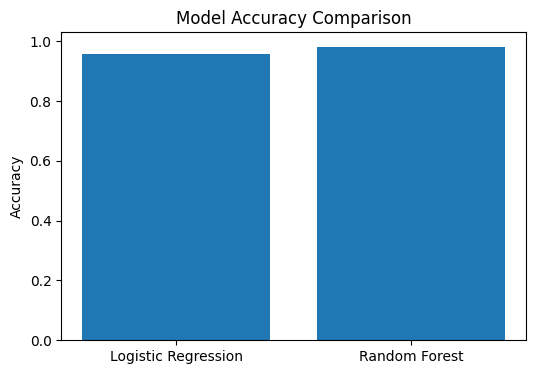

In [18]:
lr_acc = accuracy_score(y_test, lr_pred)
rf_acc = accuracy_score(y_test, rf_pred)

models = [
    "Logistic Regression",
    "Random Forest"
]

scores = [
    lr_acc,
    rf_acc
]

plt.figure(figsize=(6,4))
plt.bar(models, scores)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

**CONCLUSION**

The model with the highest Accuracy and ROC-AUC score can be selected as the best model for spam detection. The developed classification system can effectively distinguish spam messages from legitimate messages and demonstrates the practical use of machine learning for text classification tasks.